In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

In [2]:
df = pd.read_csv("../data/processed/online_retail_final.csv")

df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue,InvoiceMonth,InvoiceYear,InvoiceDay,InvoiceHour,IsWeekend
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30,2010-12,2010,Wednesday,8,False
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,2010-12,2010,Wednesday,8,False
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00,2010-12,2010,Wednesday,8,False
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,2010-12,2010,Wednesday,8,False
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,2010-12,2010,Wednesday,8,False


In [3]:
df.info()
df.describe()
df.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 392692 entries, 0 to 392691
Data columns (total 14 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   InvoiceNo     392692 non-null  int64  
 1   StockCode     392692 non-null  object 
 2   Description   392692 non-null  object 
 3   Quantity      392692 non-null  int64  
 4   InvoiceDate   392692 non-null  object 
 5   UnitPrice     392692 non-null  float64
 6   CustomerID    392692 non-null  int64  
 7   Country       392692 non-null  object 
 8   Revenue       392692 non-null  float64
 9   InvoiceMonth  392692 non-null  object 
 10  InvoiceYear   392692 non-null  int64  
 11  InvoiceDay    392692 non-null  object 
 12  InvoiceHour   392692 non-null  int64  
 13  IsWeekend     392692 non-null  bool   
dtypes: bool(1), float64(2), int64(5), object(6)
memory usage: 39.3+ MB


(392692, 14)

In [5]:
df.columns

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country', 'Revenue', 'InvoiceMonth',
       'InvoiceYear', 'InvoiceDay', 'InvoiceHour', 'IsWeekend'],
      dtype='object')

In [6]:
df["TotalPrice"] = df["Quantity"] * df["UnitPrice"]

In [7]:
df.to_csv("../data/processed/online_retail_final.csv", index=False)

In [8]:
df.head()
df.columns

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country', 'Revenue', 'InvoiceMonth',
       'InvoiceYear', 'InvoiceDay', 'InvoiceHour', 'IsWeekend', 'TotalPrice'],
      dtype='object')

In [9]:
df["TotalPrice"] = df["Quantity"] * df["UnitPrice"]

Sales Distribution

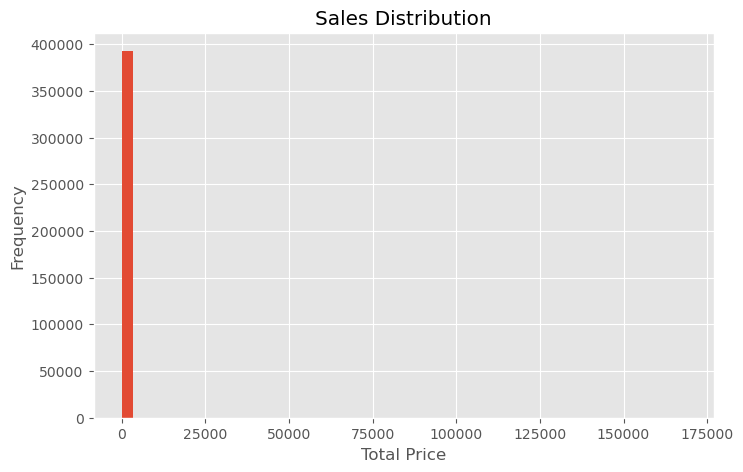

In [10]:
plt.figure(figsize=(8,5))
plt.hist(df["TotalPrice"], bins=50)

plt.title("Sales Distribution")
plt.xlabel("Total Price")
plt.ylabel("Frequency")
plt.show()

Top 10 Countries

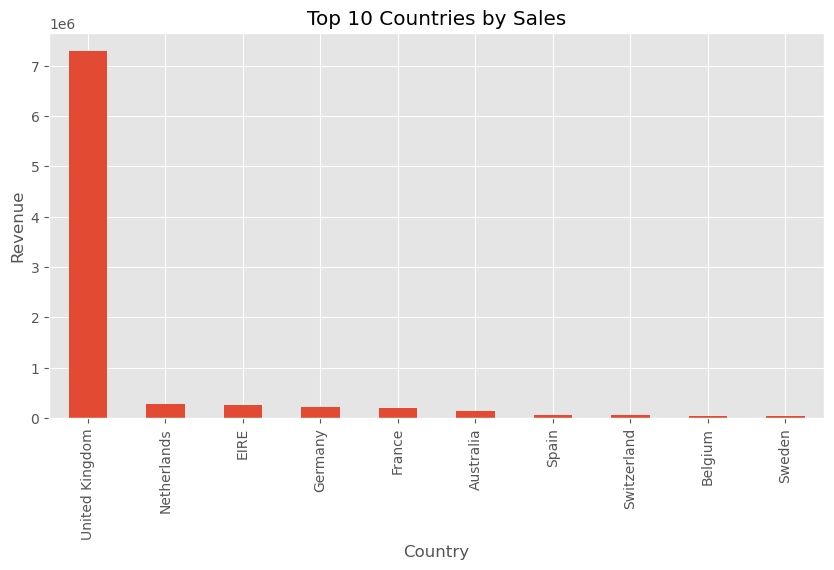

In [11]:
country_sales = df.groupby("Country")["TotalPrice"].sum().sort_values(ascending=False).head(10)

country_sales.plot(kind="bar", figsize=(10,5))

plt.title("Top 10 Countries by Sales")

plt.ylabel("Revenue")

plt.show()

In [13]:
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

In [14]:
df["YearMonth"] = df["InvoiceDate"].dt.to_period("M").astype(str)

Monthly Revenue

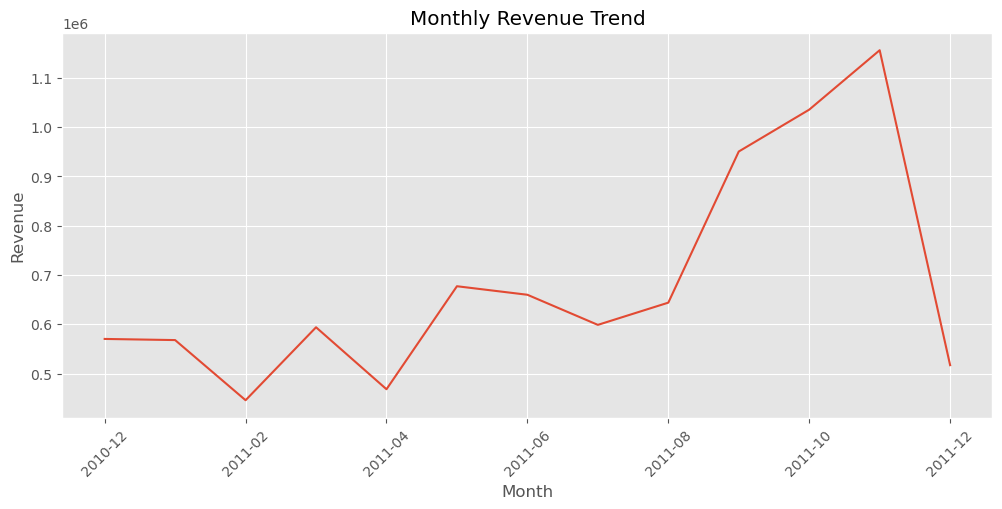

In [15]:
monthly_sales = df.groupby("YearMonth")["TotalPrice"].sum()

monthly_sales.plot(figsize=(12,5))

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")

plt.xticks(rotation=45)

plt.show()

Top Customers

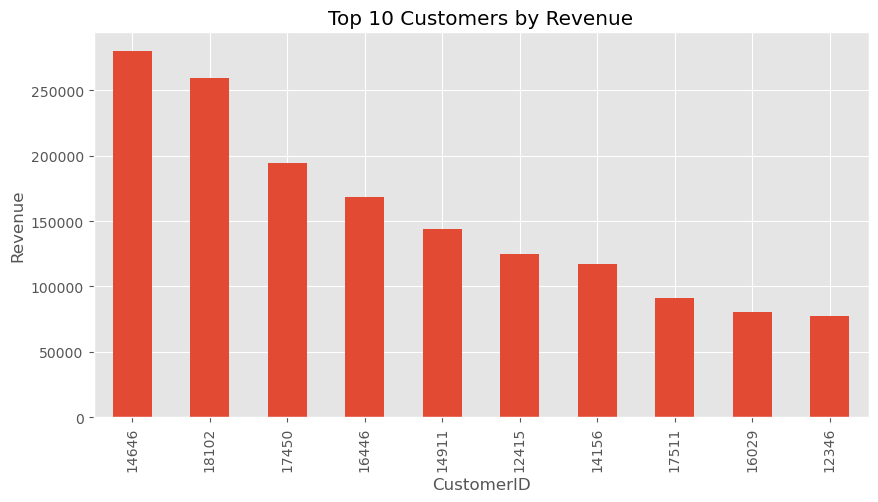

In [16]:
top_customers = df.groupby("CustomerID")["TotalPrice"].sum().sort_values(ascending=False).head(10)

top_customers.plot(kind="bar", figsize=(10,5))

plt.title("Top 10 Customers by Revenue")

plt.ylabel("Revenue")

plt.show()

Top Selling Products

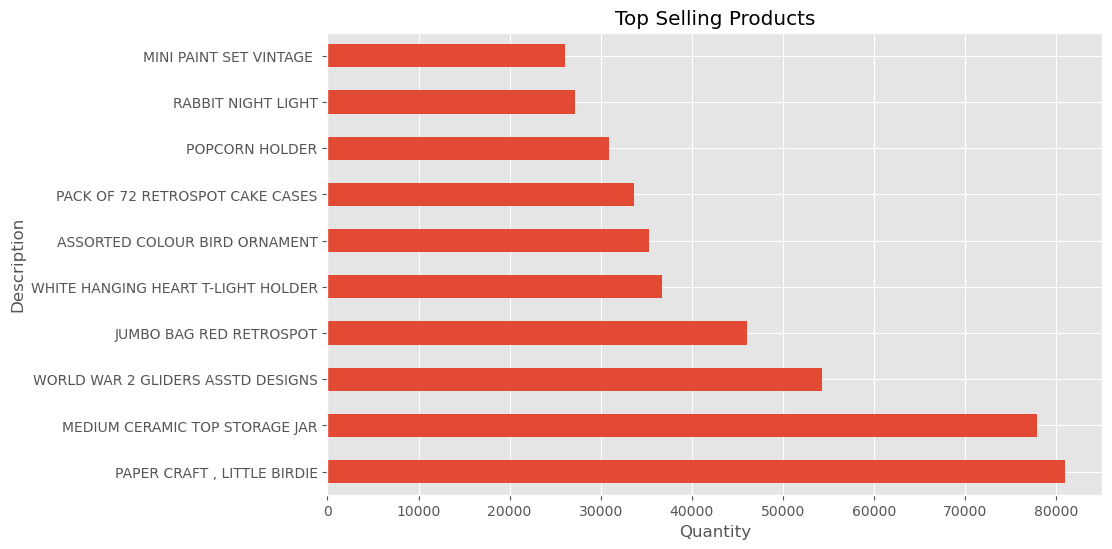

In [17]:
top_products = df.groupby("Description")["Quantity"].sum().sort_values(ascending=False).head(10)

top_products.plot(kind="barh", figsize=(10,6))

plt.title("Top Selling Products")

plt.xlabel("Quantity")

plt.show()

Correlation Heatmap

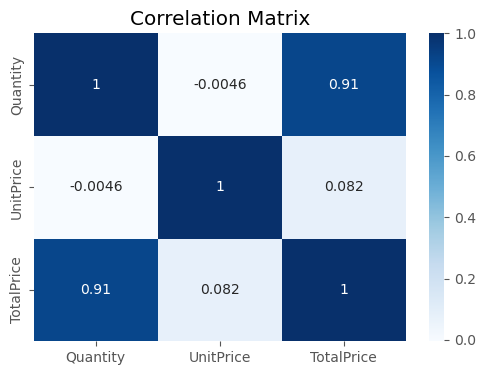

In [18]:
corr = df[["Quantity","UnitPrice","TotalPrice"]].corr()

plt.figure(figsize=(6,4))

sns.heatmap(corr,
            annot=True,
            cmap="Blues")

plt.title("Correlation Matrix")

plt.show()

Revenue by Country

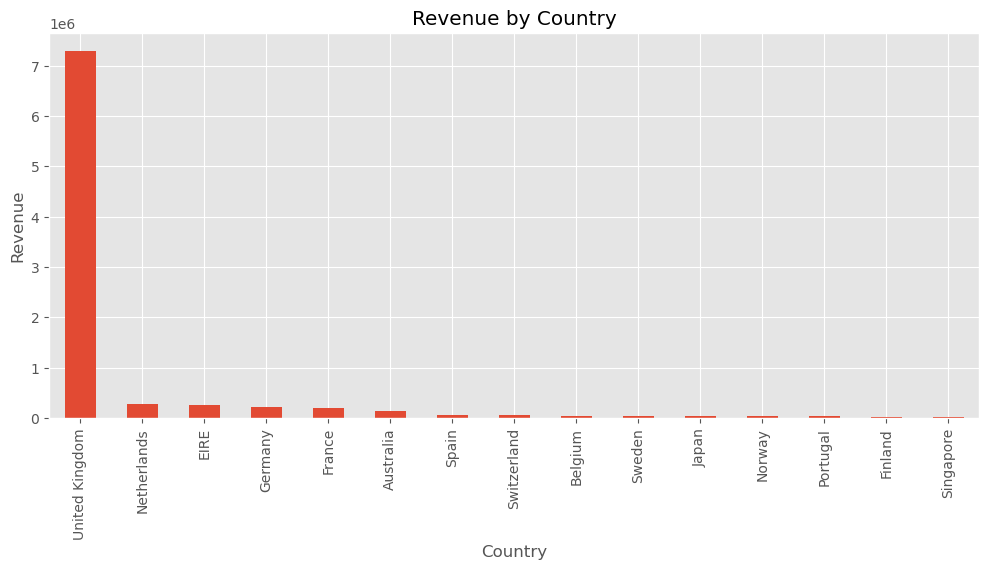

In [19]:
revenue_country = df.groupby("Country")["TotalPrice"].sum().sort_values(ascending=False).head(15)

revenue_country.plot(kind="bar", figsize=(12,5))

plt.title("Revenue by Country")

plt.ylabel("Revenue")

plt.show()

Orders per Customer

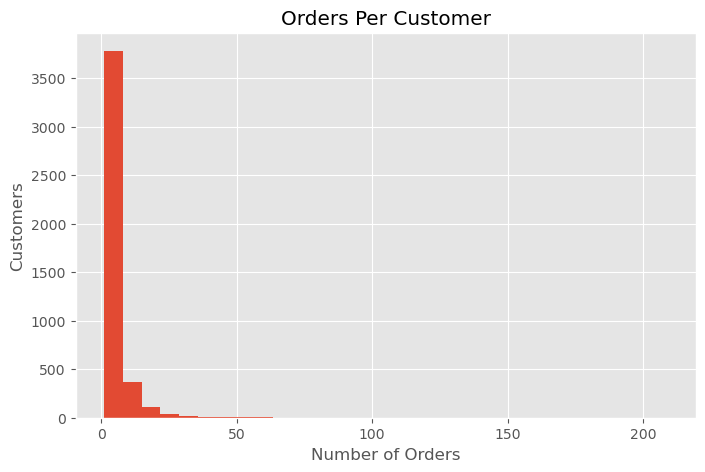

In [20]:
orders = df.groupby("CustomerID")["InvoiceNo"].nunique()

plt.figure(figsize=(8,5))

plt.hist(orders, bins=30)

plt.title("Orders Per Customer")

plt.xlabel("Number of Orders")

plt.ylabel("Customers")

plt.show()

# Key Insights

1. Majority of orders are low-value purchases.
2. A small number of customers generate a large share of revenue.
3. Revenue is concentrated in a few countries.
4. Some products contribute significantly to total sales.
5. Monthly sales fluctuate, indicating seasonality.
6. Quantity and TotalPrice show a positive relationship.
7. Customer purchasing behavior varies across the dataset.